In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
from sympy import pi, symbols, expand, sqrt, gamma, Rational, exp, simplify, integrate, oo, erf
# from sympy.stats import Gamma
from spb import plot3d_parametric_surface, PB, plot

# $\chi^2$ Distribution

In [5]:
from scipy.stats import chi2

## Introduction

A **chi-square random variable** is a non-negative random variable that is the sum of the squares of $k$ independent **standard normal random variables** ($Z\sim\mathcal{N}(0, 1)$), represented as 
$$X^{2}=Z_{1}^{2}+Z_{2}^{2}+\dots +Z_{k}^{2}.$$
It is characterized by a single parameter, the **degrees of freedom** ($df$), which is equal to $k$. 

## Distribution

In [22]:
df = 7

### $\Gamma$ function

The **gamma function**, denoted as $\Gamma (z)$, is a generalization of the factorial function to real and complex numbers. 

It is defined by the integral 

$$\Gamma (z)=\int_{0}^{\infty}t^{z-1}e^{-t}dt$$

for complex numbers with a positive real part. 

For a positive integer $n$, $\Gamma (n+1)=n!$, and the function satisfies the property $\Gamma (z+1)=z\Gamma (z)$. 

In [7]:
x = symbols('x', real=True)
gamma(Rational(1, 2))

sqrt(pi)

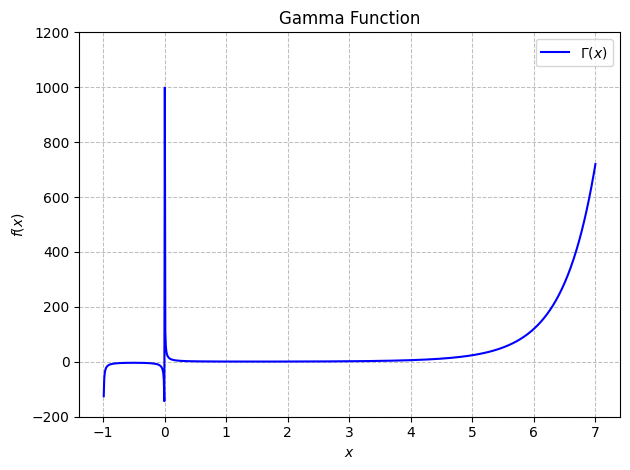

In [15]:
p1 = plot(gamma(x), (x, -1, 7), ylim=(-200,1200), line_color='blue', show=False, 
    title="Gamma Function",
    legend=True)
p1.show()

### Probability Density Function (`.pdf`)

The probability density function (pdf) of the chi-squared distribution is
$$f(x, k) = \left\{\begin{matrix}
\frac{x^{k/2-1}e^{-x/2}}{2^{k/2}\Gamma \big(\frac{k}{2}\big)}, & x > 0 \\
 0, &  \text{otherwise}\\
\end{matrix}\right.$$

In [5]:
chi2.pdf(6, df=df)

np.float64(0.11676521599113948)

In [ ]:
x, k = symbols('x k')
pdf = x**(k/2-1)*exp(x/2)

### Cumulative Distribution Function (`.cdf`)

In [5]:
# Calculate CDF at a specific value
cdf_at_6 = chi2.cdf(6, df=df)
print(f"CDF at x=6: {cdf_at_6}")

CDF at x=6: 0.4602506496044429


### Quantiles (`.ppf`)

In [6]:
# Calculate PPF (quantile function)
# This finds the value x for which the CDF is equal to a given probability
ppf_value = chi2.ppf(0.95, df=df)
print(f"95th percentile: {ppf_value}")

95th percentile: 14.067140449340169


### Mean or expected value (`.mean`)

In [9]:
chi2.mean(df=df)

np.float64(7.0)

### Variances (`.var`) and Standard Deviation (`.std`)

In [4]:
chi2.var(df=df)

np.float64(14.0)

In [5]:
chi2.std(df=df)

np.float64(3.7416573867739413)

## Unbiased Sample Variance and Chi-square distribution

For a random samples of normal distribution

$$\frac{(n-1)s_n^2}{\sigma^2} \sim \chi_{n-1}^2,$$

where 
\begin{equation*}
s_n^2 = \frac{1}{n-1}\sum_{k=1}^n (X_k - \bar{X})^2
\end{equation*}

## Visualization

### Histplot

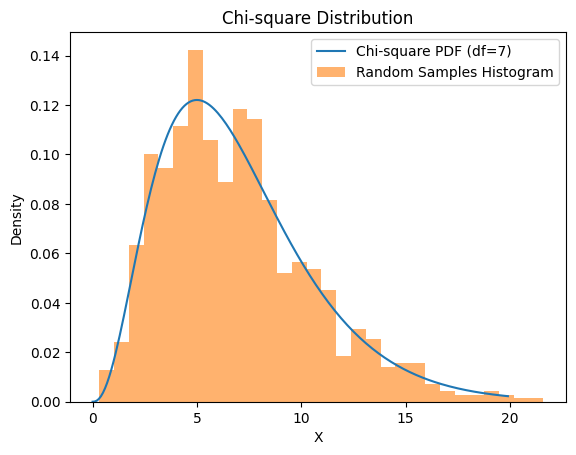

In [26]:
df = 7
# Generate random deviates using scipy.stats
random_deviates = chi2.rvs(df=df, size=1000)

# Calculate PDF at specific values
x_values = np.arange(0, 20, 0.1)
pdf_values = chi2.pdf(x_values, df=df)

# Plotting the PDF and a histogram of generated samples
plt.plot(x_values, pdf_values, label=f'Chi-square PDF (df={df})')
plt.hist(random_deviates, bins=30, density=True, alpha=0.6, label='Random Samples Histogram')
plt.title('Chi-square Distribution')
plt.xlabel('X')
plt.ylabel('Density')
plt.legend()
plt.show()

Chi squared is a continuous, right-skewed distribution, always $\geq0$, with $k$ degrees of freedom.

### Degree of Freedom

In [21]:
x_values = np.arange(0, 40, 0.1)
data = pd.DataFrame({'x': x_values})
for degreeFreedom in np.arange(7, 21):
    data[degreeFreedom]=chi2.pdf(x_values, df=degreeFreedom)
    
chi_df = pd.melt(data, id_vars=['x'], value_vars=list(np.arange(7, 21)), var_name="degree_of_freedom", value_name="pdf")

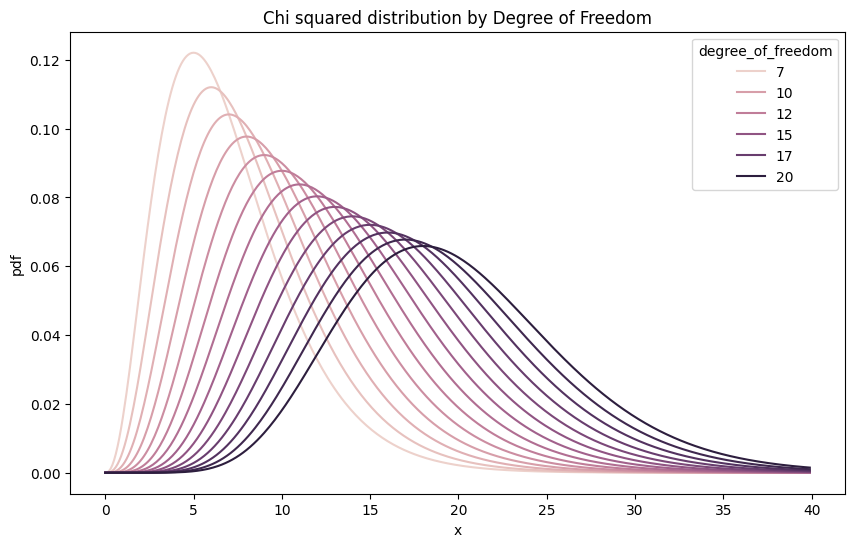

In [22]:
# Plotting 'pdf' over 'x' for each 'degree_of_freedom'
plt.figure(figsize=(10, 6))
sns.lineplot(data=chi_df, x="x", y="pdf", hue="degree_of_freedom")

plt.title("Chi squared distribution by Degree of Freedom")
plt.show()

- The shape of the distribution is determined by this parameter, which represents the number of independent variables summed.

- The distribution is non-negative and highly right-skewed, particularly with fewer degrees of freedom. As the degrees of freedom increase, it approaches a normal distribution.

# References

- [Why is the sample variance distributed with n-1 degrees of freedom?](https://towardsdatascience.com/why-is-the-sample-variance-distributed-with-n-1-degrees-of-freedom-c9edcdada28b)